## Imports

In [1]:
import sys

sys.path.append("../src/")

In [2]:
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation

from utils.data_utils import (
    get_train_test_ranges,
    data_CNN_Disk,
    data_CNN_Disk_steps,
    gen_3D_data,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_KE,
    compute_nino34,
    compute_amo,
    gen_KE_range,
    gen_value_range,
    compute_mean_single,
)
from utils.climate_utils import compute_laplacian_wet

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
import copy
from datetime import datetime
import os

## 3D Fields

### G3D All

In [3]:
# $$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
### Convnext unet
# $$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

# 5 Levels
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_5",
#         overrides=[
# "output_dir=./temp/{0}_ConvNextUNetTrain3DEval3DHist1Levels5".format(
#     str(datetime.now())[:10]
# ),
# "network={0}_ConvNextUNetTrain3DEval3DHist1Levels5".format(
#     str(datetime.now())[:10]
# ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-07-19-train_convnextunet_global_3D_hist1_5levels_out2/out2/saved_nets/convnextunet_epoch_20_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[80,100,150,300,400]",
#             "run_gen_pred=True",
#             "N_samples=4000",
#             "N_val=340",
#             "N_test=400",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all"
#         ],
#     )

########################################################

# All Levels - v0.2.1, Hist = 1
with initialize_config_dir(
    version_base=None,
    config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
):
    args = compose(
        config_name="exp/eval_unet_global_3D_all",
        overrides=[
            "output_dir=./temp/{0}_ConvNextUNetTrain3Dv021Eval3DEpochs70Epoch70".format(
                str(datetime.now())[:10]
            ),
            "network={0}_ConvNextUNetTrain3Dv021Eval3DEpochs70Epoch70".format(
                str(datetime.now())[:10]
            ),
            "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-08-19-convnextunet_v021_hist1_70epochs/aaa/saved_nets/convnextunet_epoch_70_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
            "hist=1",
            "unet.ch_width=[157,200,250,300,400]",
            "run_gen_pred=True",
            "N_samples=4000",
            "N_val=140",
            "N_test=600",
            "pred_names=null",
            "pred_paths=null",
            "+dataset_name=OM4",
            "train_region=global_3D",
            "region=global_3D",
            "model_name_replace=Convnext",
            "depth_mode=all",
        ],
    )

########################################################

# All Levels - v0, Hist = 1, 40M
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3Dv0.0_all.yaml",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3DEval3D40MEpochs35Epoch20".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3DEval3D40MEpochs35Epoch20".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-08-07-convnextunet_hist1_out2_40M_35epochs/40/saved_nets/convnextunet_epoch_20_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "N_samples=4000",
#             "N_val=140",
#             "N_test=600",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )

######################################################

########################################################

# All Levels - v0, Hist = 1, Pred Residuals
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3Dv0.0_all.yaml",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3DEval3DResidualEpochs35Epoch20".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3DEval3DResidualEpochs35Epoch20".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-08-09-convnextunet_hist1_out2_residuals_35epochs/ers/saved_nets/convnextunet_epoch_20_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "unet.pred_residuals=True",
#             "N_samples=4000",
#             "N_val=140",
#             "N_test=600",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )

########################################################

# All Levels - Hist = 1, 100 year emulation
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3DEval3DHist1Epoch20Years100-1996".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3DEval3DHist1Epoch20Years100-1996".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-07-25-convnextunet_hist1_out2_35epochs/convnextunet_epoch_20_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "N_samples=0",
#             "N_val=0",
#             "N_test=3000",
#             "data_zarr=3D_data_100_years",
#             "data_means_zarr=3D_data_100_years_means",
#             "data_stds_zarr=3D_data_100_years_stds",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4_1996_repeat",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )


########################################################

# All Levels - Hist = 1, 10 years
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all_10yrs",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3DEval3D10yrsEpoch24".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3DEval3D10yrsEpoch24".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-08-03-convnextunet_hist1_out2_10yrs_35epochs/10/saved_nets/convnextunet_epoch_24_beststeps_4_global_3D_all_N_train_730_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )

########################################################

# All Levels - Hist = 1, SST
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all_SST",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3DEval3DSSTEpoch35".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3DEval3DSSTEpoch35".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-08-01-convnextunet_hist1_out2_SSTBoundary_35epochs/sst/saved_nets/convnextunet_epoch_35_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#             "hist=1",
#             "unet.ch_width=[157,200,250,300,400]",
#             "run_gen_pred=True",
#             "N_samples=4000",
#             "N_val=140",
#             "N_test=600",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )

########################################################

# All Levels - Hist = 0
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_unet_global_3D_all",
#         overrides=[
#             "output_dir=./temp/{0}_ConvNextUNetTrain3DEval3DHist0Epoch20".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_ConvNextUNetTrain3DEval3DHist0Epoch20".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-08-16-convnextunet_v021float64_hist0_35epochs_randseed10/ihst0/saved_nets/convnextunet_epoch_20_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#             "hist=0",
#             "unet.ch_width=[80,100,150,300,400]",
#             "run_gen_pred=True",
#             "N_samples=4000",
#             "N_val=140",
#             "N_test=600",
#             "pred_names=null",
#             "pred_paths=null",
#             "+dataset_name=OM4",
#             "train_region=global_3D",
#             "region=global_3D",
#             "model_name_replace=Convnext",
#             "depth_mode=all",
#         ],
#     )

########################################################

# $$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
### Swin
# $$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
# with initialize_config_dir(
#     version_base=None,
#     config_dir="/pscratch/sd/s/suryad/Ocean_Emulator/configs",
# ):
#     args = compose(
#         config_name="exp/eval_swin_global_3D_all",
#         overrides=[
#             "output_dir=./temp/{0}_SwinTrain3DSurfaceEval3DHist1Epoch35".format(
#                 str(datetime.now())[:10]
#             ),
#             "network={0}_SwinTrain3DSurfaceEval3DHist1Epoch35".format(
#                 str(datetime.now())[:10]
#             ),
#             "ckpt_path=[/pscratch/sd/s/suryad/Ocean_Emulator/train_3D/2024-08-01-train_swin_global_3D_all_out2_35epochs/swin/saved_nets/swin_epoch_35_steps_4_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#             "run_gen_pred=True",  # Done Generation
#             "hist=1",
#             "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
#             "swin.embed_dim=180",
#             "N_samples=4000",
#             "N_val=140",
#             "N_test=600",
#             "pred_names=null",
#             "pred_paths=null",
#             "model_name_replace=Swin",
#             "train_region=global_3D",
#             "region=global_3D",
#             "depth_mode=all",
#             "+dataset_name=OM4",
#         ],
#     )

if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

### G3D Surface

In [24]:
# G3D Surface
with initialize_config_dir(
    version_base=None,
    config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs",
):
    args = compose(
        config_name="exp/eval_unet_global_3D",
        overrides=[
            "output_dir=./temp/{0}_convnext_3D_surface_from_disk".format(
                str(datetime.now())[:10]
            ),
            "model_name_replace=Convnext",
            "network=ConvNext UNet Train3DSurfaceEval3DSurfacewithoutso",
            "data_dir=/dummypath",
            "train_region=global_3D",
            "region=global_3D",
            "depth_mode=surface",
            "save_test_data=False",  # Done Generation
            "save_clim_data=False",  # Done Generation
            "N_samples=4000",
            "N_val=140",
            "N_test=600",
            "run_gen_pred=True",  # Done Generation
            "ckpt_path=[/scratch/lvb243/Ocean_Emulator/train_3D/2024-06-26-train_convnextunet_global_3D_surface_without_so/3D/saved_nets/convnextunet_best_steps_4_global_3D_surface_N_train_4000_Lateral_Data_025_no_smooth.pt]",
            "pred_names=null",
            "pred_paths=null",
            "+dataset_name=OM4",
        ],
    )
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

## Init

In [4]:
inputs_str = INPT_VARS[args.exp_num_in]
extra_in_str = EXTRA_VARS[args.exp_num_extra]
outputs_str = OUT_VARS[args.exp_num_out]
levels = args.exp_num_in.split("_")[-1]
if levels == "all":
    levels = 19
else:
    levels = int(levels)

str_in = "".join([i + "_" for i in inputs_str])
str_ext = "".join([i + "_" for i in extra_in_str])
str_out = "".join([i + "_" for i in outputs_str])

print("inputs: " + str_in)
print("extra inputs: " + str_ext)
print("outputs: " + str_out)
print("levels: " + str(levels))
N_atm = len(extra_in_str)  # Number of atmosphere variables
N_in = len(inputs_str)
if args.lateral:
    N_extra = (
        N_atm + N_in
    )  # Number of atmosphere variables + Lateral boundary variables
else:
    N_extra = N_atm  # Number of atmosphere variables
N_out = (args.hist + 1) * len(outputs_str)

num_in = int((args.hist + 1) * N_in + N_extra)

print("Number of inputs: ", num_in)  # 3 (ocean speeds + ocean temp)(t) +
# 3 (atm wind stresses + atm temp)(t) +
# 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
print("Number of outputs: ", N_out)  # 3

if "swin" in args.network.lower():
    model = instantiate(
        args.swin,
        in_channels=self.num_in,
        output_channels=self.N_out,
        pretrain_img_size=[180, 360],
        wet=self.wet.cuda(),
        hist=args.hist,
    )
elif "convnext" in args.network.lower():
    if args.unet.ch_width[0] != num_in:
        print(
            "Changing ch_width to match number of inputs {0} -> {1}".format(
                args.unet.ch_width[0], num_in
            )
        )
        args.unet.ch_width[0] = num_in

# Post-fix strings
str_train = (
    "steps_"
    + str(args.steps)
    + "_"
    + args.train_region
    + "_"
    + args.depth_mode
    + "_N_train_4000"
    + "_Lateral_Data_025_no_smooth"
)
str_save = (
    "steps_"
    + str(args.steps)
    + "_"
    + args.train_region
    + "_"
    + args.region
    + "_"
    + args.depth_mode
    + "+N_samples_"
    + str(args.N_samples)
)
post_model_name = (
    "Train_"
    + args.train_region
    + "_Test_"
    + args.region
    + "_"
    + args.depth_mode
    + "_N_train_"
    + str(args.N_samples)
    + "_Lateral_Data_025_no_smooth"
)
post_pred_name = (
    args.region + "_" + args.depth_mode + "_N_samples_" + str(args.N_samples)
)

# Getting start and end indices of train and test
s_train, e_train, e_test = get_train_test_ranges(
    args.N_samples, args.N_val, args.lag, args.hist, args.interval
)
dataset_name = args.dataset_name

if "OM4" in dataset_name:
    timestep_str = "\\times 5"
else:
    raise ValueError("Dataset not recognized")

inputs: uo_lev_2_5_uo_lev_10_0_uo_lev_22_5_uo_lev_40_0_uo_lev_65_0_uo_lev_105_0_uo_lev_165_0_uo_lev_250_0_uo_lev_375_0_uo_lev_550_0_uo_lev_775_0_uo_lev_1050_0_uo_lev_1400_0_uo_lev_1850_0_uo_lev_2400_0_uo_lev_3100_0_uo_lev_4000_0_uo_lev_5000_0_uo_lev_6000_0_vo_lev_2_5_vo_lev_10_0_vo_lev_22_5_vo_lev_40_0_vo_lev_65_0_vo_lev_105_0_vo_lev_165_0_vo_lev_250_0_vo_lev_375_0_vo_lev_550_0_vo_lev_775_0_vo_lev_1050_0_vo_lev_1400_0_vo_lev_1850_0_vo_lev_2400_0_vo_lev_3100_0_vo_lev_4000_0_vo_lev_5000_0_vo_lev_6000_0_thetao_lev_2_5_thetao_lev_10_0_thetao_lev_22_5_thetao_lev_40_0_thetao_lev_65_0_thetao_lev_105_0_thetao_lev_165_0_thetao_lev_250_0_thetao_lev_375_0_thetao_lev_550_0_thetao_lev_775_0_thetao_lev_1050_0_thetao_lev_1400_0_thetao_lev_1850_0_thetao_lev_2400_0_thetao_lev_3100_0_thetao_lev_4000_0_thetao_lev_5000_0_thetao_lev_6000_0_so_lev_2_5_so_lev_10_0_so_lev_22_5_so_lev_40_0_so_lev_65_0_so_lev_105_0_so_lev_165_0_so_lev_250_0_so_lev_375_0_so_lev_550_0_so_lev_775_0_so_lev_1050_0_so_lev_1400_0_so_l

In [5]:
print("Calculating mask tensors")

ds = xr.open_zarr(os.path.join("/pscratch/sd/s/suryad/data", args.raw_data_zarr))
ds = ds.drop(["tauuo", "tauvo", "hfds"])
lev_map = {str(lev).replace(".", "_"): i for i, lev in enumerate(ds["lev"].values)}


def get_wet_mask(inputs, device="cpu"):
    wet = xr.zeros_like(inputs[0][0])
    # inputs[0][0,12,12] = np.nan
    for ds in inputs:
        wet += np.isnan(ds[0])

    wet_nan = xr.where(wet != 0, np.nan, 1).to_numpy()
    wet = np.isnan(xr.where(wet == 0, np.nan, 0))
    wet = np.nan_to_num(wet.to_numpy())
    wet = torch.from_numpy(wet).type(torch.float32).to(device=device)
    return wet, wet_nan


if args.depth_mode == "surface":
    inputs, extra_in, outputs = gen_3D_data(
        os.path.join("/pscratch/sd/s/suryad/data", args.raw_data_zarr),
        inputs_str,
        extra_in_str,
        outputs_str,
        args.lag,
        depth_mode=args.depth_mode,
    )
    wet, wet_nan = get_wet_mask(inputs, "cpu")
    wet_bool = np.array(wet.cpu()).astype(bool)
    wet_lap = compute_laplacian_wet(wet_nan, 4)  # hardcoded
    wet_lap = xr.where(wet_lap == 0, 1, np.nan)
    wet_lap = np.nan_to_num(wet_lap)


elif args.depth_mode == "all":
    wet_stacked = []
    wet_nan_stacked = []
    for i, lev in enumerate(ds["lev"].values):
        inputs = []
        inputs.append(ds["uo"].sel(lev=lev))
        inputs.append(ds["vo"].sel(lev=lev))
        inputs.append(ds["thetao"].sel(lev=lev))
        inputs.append(ds["so"].sel(lev=lev))
        if i == 0:
            inputs.append(ds["zos"])

        inputs = tuple(inputs)
        wet, wet_nan = get_wet_mask(inputs)
        wet_stacked.append(wet)
        wet_nan_stacked.append(wet_nan)

    wet_3D = torch.stack(wet_stacked)
    wet_nan_3D = np.stack(wet_nan_stacked)

    final_wet = []
    final_wet_nan = []
    for var in inputs_str:
        try:
            level = lev_map[var.split("lev_")[-1]]
        except:
            print("Exception at : ", var)
            level = 0
        final_wet.append(wet_3D[level])
        final_wet_nan.append(wet_nan_3D[level])

    wet = torch.stack(final_wet)
    wet_nan = np.stack(final_wet_nan)

    wet_bool = np.array(wet.cpu()).astype(bool)
    # wet_lap = compute_laplacian_wet(wet_nan, 4)  # hardcoded
    # wet_lap = xr.where(wet_lap == 0, 1, np.nan)
    # wet_lap = np.nan_to_num(wet_lap)

wet = torch.concat([wet] * (args.hist + 1), dim=0)
print("Wet resolution:", wet.shape)
time_vec = inputs[0].time.data
time_test = time_vec[e_test : (e_test + args.lag * args.N_test)]

Calculating mask tensors
Exception at :  zos
Wet resolution: torch.Size([154, 180, 360])


In [6]:
import xarray as xr
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
from scipy.ndimage import gaussian_filter
from einops import rearrange
import os


class data_CNN_Disk(torch.utils.data.Dataset):

    def __init__(
        self,
        data,
        inputs_str,
        extra_in_str,
        outputs_str,
        wet,
        data_mean,
        data_std,
        n_samples,
        lag,
        interval,
        hist,
        ind_start,
        long_rollout,
        device="cuda",
    ):
        super().__init__()
        self.device = device

        self.size = n_samples
        self.lag = lag
        self.interval = interval
        self.hist = hist
        self.ind_start = ind_start

        assert self.interval == 1
        assert self.lag == 1

        data = data.isel(time=slice(self.ind_start, None))
        self.inputs = data[inputs_str + extra_in_str]
        self.outputs = data[outputs_str]
        self.inputs_no_extra = data[inputs_str]
        self.extras = data[extra_in_str]

        # This class will be used only for validation and rollouts
        # Rolling indices to keep track of histories/past states:
        # HIST=0 ; 0->[0, 1]; 1->[1, 2]; 2->[2, 3]; 3->[3, 4]
        # HIST=1 ; 0->[[0, 1], [2, 3]]; 1->[[2, 3], [4, 5]]; 2->[[4, 5], [6, 7]]; 3->[[6, 7], [8, 9]]
        # HIST=2 ; 0->[[0, 1, 2], [3, 4, 5]]; 1->[[3, 4, 5], [6, 7, 8]]; 2->[[6, 7, 8], [9, 10, 11]]; 3->[[9, 10, 11], [12, 13, 14]]
        indices = xr.DataArray(
            np.arange(data.time.size),
            dims=["time"],
            coords={"time": data.time},
        )
        total_steps = 2 * self.hist + 1
        rolling_indices = (
            indices.rolling(time=len(data.time) - total_steps, center=False)
            .construct("window_dim")
            .astype(int)
        )
        rolling_indices = rolling_indices.transpose("window_dim", "time").isel(
            time=slice(len(data.time) - total_steps - 1, None)
        )  # Remove first few null indices
        self.rolling_indices = rolling_indices.isel(
            window_dim=slice(0, None, self.hist + 1)
        )  # Skip indices based on history

        if long_rollout:
            window0 = self.rolling_indices.isel(window_dim=0)
            print(
                "Long rollout will begin with input and produce output from time index {0} and {1} respectively".format(
                    window0.isel(time=0).values + ind_start,
                    window0.isel(time=self.hist + 1).values + ind_start,
                )
            )

        self.in_mean = data_mean[inputs_str + extra_in_str]
        self.in_std = data_std[inputs_str + extra_in_str]
        self.out_mean = data_mean[outputs_str]
        self.out_std = data_std[outputs_str]
        self.inputs_no_extra_mean = data_mean[inputs_str]
        self.inputs_no_extra_std = data_std[inputs_str]
        self.extras_mean = data_mean[extra_in_str]
        self.extras_std = data_std[extra_in_str]

        self.wet = wet

    def set_device(self, device):
        self.device = device

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        if type(idx) == slice:
            if idx.start == None and idx.stop == None:
                idx = slice(0, self.size, idx.step)
            elif idx.start == None:
                idx = slice(0, idx.stop, idx.step)
            elif idx.stop == None:
                idx = slice(idx.start, self.size, idx.step)
        elif type(idx) == int:
            idx = slice(idx, idx + 1, 1)

        rolling_idx = self.rolling_indices.isel(window_dim=idx)
        x_index = xr.Variable(["window_dim", "time"], rolling_idx)
        print(
            "Out: ",
            (self.ind_start + x_index.isel(time=slice(self.hist + 1, None))).values,
            end=" ",
        )
        data_in = self.inputs_no_extra.isel(time=x_index).isel(
            time=slice(None, self.hist + 1)
        )
        data_in = (
            (data_in - self.inputs_no_extra_mean) / self.inputs_no_extra_std
        ).fillna(0)
        data_in = (
            data_in.to_array()
            .transpose("window_dim", "time", "variable", "y", "x")
            .to_numpy()
        )
        data_in = rearrange(
            data_in, "window_dim time variable y x -> window_dim (time variable) y x"
        )
        data_in_boundary = self.extras.isel(time=x_index).isel(time=self.hist)
        data_in_boundary = (
            (data_in_boundary - self.extras_mean) / self.extras_std
        ).fillna(0)
        data_in_boundary = (
            data_in_boundary.to_array()
            .transpose("window_dim", "variable", "y", "x")
            .to_numpy()
        )
        data_in = np.concatenate((data_in, data_in_boundary), axis=1)

        label = self.outputs.isel(time=x_index).isel(time=slice(self.hist + 1, None))
        label = ((label - self.out_mean) / self.out_std).fillna(0)
        label = (
            label.to_array()
            .transpose("window_dim", "time", "variable", "y", "x")
            .to_numpy()
        )
        label = rearrange(
            label, "window_dim time variable y x -> window_dim (time variable) y x"
        )

        items = (torch.from_numpy(data_in).float(), torch.from_numpy(label).float())

        return items

In [7]:
import xarray as xr

assert args.depth_mode == "surface" or args.depth_mode == "all"

if args.depth_mode == "surface":
    wet = torch.load(os.path.join("/pscratch/sd/s/suryad/data", args.surface_wet_file))
    wet_bool = np.array(wet.cpu()).astype(bool)
    data = xr.open_zarr(os.path.join("/pscratch/sd/s/suryad/data", args.data_zarr))
    data_mean = xr.open_zarr(
        os.path.join("/pscratch/sd/s/suryad/data", args.data_means_zarr)
    )
    data_std = xr.open_zarr(
        os.path.join("/pscratch/sd/s/suryad/data", args.data_stds_zarr)
    )
elif args.depth_mode == "all":
    data = xr.open_zarr(os.path.join("/pscratch/sd/s/suryad/data", args.data_zarr))
    data_mean = xr.open_zarr(
        os.path.join("/pscratch/sd/s/suryad/data", args.data_means_zarr)
    )
    data_std = xr.open_zarr(
        os.path.join("/pscratch/sd/s/suryad/data", args.data_stds_zarr)
    )

train_data = data_CNN_Disk_steps(
    data,
    inputs_str,
    extra_in_str,
    outputs_str,
    wet,
    data_mean,
    data_std,
    args.N_samples,
    args.lag,
    args.interval,
    args.hist,
    args.steps,
    device="cuda",
)

test_data = data_CNN_Disk(
    data,
    inputs_str,
    extra_in_str,
    outputs_str,
    wet,
    data_mean,
    data_std,
    args.N_test,
    args.lag,
    args.interval,
    args.hist,
    e_test,
    long_rollout=True,
    device="cuda",
)

/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Long rollout will begin with input and produce output from time index 4141 and 4143 respectively


In [8]:
# Model
print("Loading model " + args.network)
if "swin" in args.network.lower():
    model = instantiate(
        args.swin,
        in_channels=num_in,
        output_channels=N_out,
        pretrain_img_size=[180, 360],
        wet=wet.cuda(),
        hist=args.hist,
    )
elif "unet" in args.network.lower():
    model = instantiate(args.unet, n_out=N_out, wet=wet.cuda(), hist=args.hist)

full_model_path = args.ckpt_path
full_model_name = args.network + "_" + post_model_name
output_channels = model.output_channels

model = model.to(args.device)
ckpt_path = args.ckpt_path
model = model

Loading model 2024-08-20_ConvNextUNetTrain3Dv021Eval3DEpochs70Epoch70


In [9]:
# Stats
mean_in = test_data.in_mean.to_array().to_numpy().reshape(-1)
std_in = test_data.in_std.to_array().to_numpy().reshape(-1)
mean_out = test_data.out_mean.to_array().to_numpy().reshape(-1)
std_out = test_data.out_std.to_array().to_numpy().reshape(-1)

test_data.norm_vals = {
    "s_out": std_out,
    "s_in": std_in,
    "m_out": mean_out,
    "m_in": mean_in,
}

In [10]:
# clim
# clim = None
# if args.save_clim_data:
#     print("Saving clim")
#     clim = np.zeros((total_steps, *wet.shape, N_out))
#     for i in range(N_out):
#         clim[:, :, :, i] = (
#             outputs[i].groupby("time.dayofyear").mean("time").data
#         )
#     torch.save(
#         clim,
#         Path(args.data_dir) / "clim_cnn_{0}.pt".format(str_save),
#     )

# else:
#     print("Loading clim")
#     clim = torch.load(
#         Path(args.data_dir) / "clim_cnn_{0}.pt".format(str_save)
#     )


# Getting area tensor
print("Computing area tensor")
# grids = xr.open_dataset(
#     os.path.join("/pscratch/sd/s/suryad/data", args.grid_file)
# ).rename({"dx": "dxu", "dy": "dyu"})

# area = torch.from_numpy(grids["area_C"].to_numpy()).to(device="cpu")
# dx = grids["dxu"].to_numpy()
# dy = grids["dyu"].to_numpy()

grids = xr.open_dataset(
    os.path.join("/pscratch/sd/s/suryad/data", args.grid_file)
).rename({"xu_ocean": "x", "yu_ocean": "y"})
area = torch.from_numpy(grids["area_C"].to_numpy()).to(device="cpu")


pred_model_path = Path("/pscratch/sd/s/suryad/Ocean_Emulator/Preds") / full_model_name
if not os.path.isdir(pred_model_path):
    os.makedirs(pred_model_path)

Nb = args.Nb
hist = args.hist
lag = args.lag
N_test = args.N_test
N_samples = args.N_samples
output_dir = args.output_dir
region = args.region
steps = args.steps
network = args.model_name_replace
inputs = inputs

pred_region = args.region
pred_names = args.pred_names if args.pred_names else []
pred_paths = args.pred_paths if args.pred_paths else []

JUPYTER_MODE = False


def send_data_to_cpu():
    test_data.set_device(device="cpu")

Computing area tensor


## Generation

In [11]:
def generate_pred_lateral():
    print("Generation Pred begin...")
    for rand_ind, model_path in enumerate(args.ckpt_path):
        print("Random seed: ", rand_ind + 1)
        # try:
        model.load_state_dict(
            torch.load(model_path, map_location=torch.device("cuda"))["model"]
        )
        # except:
        #     model.load_state_dict(
        #         torch.load(model_path, map_location=torch.device("cuda"))
        #     )

        model_pred, _ = generate_model_rollout(
            N_test,
            test_data,
            model,
            hist,
            N_in,
            N_extra,
            initial_input=None,
            Nb=0,
            region=region,
        )

        print("data_gen")
        da = xr.DataArray(
            data=model_pred,
            dims=["time", "x", "y", "var"],
        )

        da.to_zarr(
            pred_model_path
            / (
                "Pred_lateral_Fast_Data_025_"
                + post_pred_name
                + "_rand_seed_"
                + str(rand_ind + 1)
                + ".zarr"
            ),
            mode="w",
        )
        print(f"Model pred shape {model_pred.shape}")

In [12]:
%%time
if args.run_gen_pred:
    generate_pred_lateral()

Generation Pred begin...
Random seed:  1
Out:  [[4143 4144]] Out:  [[4143 4144]] Out:  [[4145 4146]] Out:  [[4147 4148]] Out:  [[4149 4150]] Out:  [[4151 4152]] Out:  [[4153 4154]] Out:  [[4155 4156]] Out:  [[4157 4158]] Out:  [[4159 4160]] Out:  [[4161 4162]] Out:  [[4163 4164]] Out:  [[4165 4166]] Out:  [[4167 4168]] Out:  [[4169 4170]] Out:  [[4171 4172]] Out:  [[4173 4174]] Out:  [[4175 4176]] Out:  [[4177 4178]] Out:  [[4179 4180]] Out:  [[4181 4182]] Out:  [[4183 4184]] Out:  [[4185 4186]] Out:  [[4187 4188]] Out:  [[4189 4190]] Out:  [[4191 4192]] Out:  [[4193 4194]] Out:  [[4195 4196]] Out:  [[4197 4198]] Out:  [[4199 4200]] Out:  [[4201 4202]] Out:  [[4203 4204]] Out:  [[4205 4206]] Out:  [[4207 4208]] Out:  [[4209 4210]] Out:  [[4211 4212]] Out:  [[4213 4214]] Out:  [[4215 4216]] Out:  [[4217 4218]] Out:  [[4219 4220]] Out:  [[4221 4222]] Out:  [[4223 4224]] Out:  [[4225 4226]] Out:  [[4227 4228]] Out:  [[4229 4230]] Out:  [[4231 4232]] Out:  [[4233 4234]] Out:  [[4235 4236]]

## Loading

In [13]:
num_seeds = 1

In [14]:
send_data_to_cpu()


def load_seeded_data(Pred_path, current_net=False):
    if current_net:
        prefix = "Pred_lateral_Fast_Data_025_" + post_pred_name + "_rand_seed_"
    else:
        prefix = (
            "Pred_lateral_Fast_Data_025_"
            + pred_region
            + "_in_"
            + str_in
            + "ext_"
            + "tau_u_tau_v_t_ref_"
            + "N_samples_"
            + str(N_samples)
            + "_rand_seed_"
        )

    model_preds = None

    for rand_seed in range(1, num_seeds + 1):
        print("Loading seed ", rand_seed)
        model_pred_net = (
            (xr.open_zarr(Path(Pred_path) / (prefix + str(rand_seed) + ".zarr")))
            .to_array()
            .to_numpy()
            .squeeze()
        )

        if model_preds is None:
            model_preds = np.zeros((num_seeds,) + model_pred_net.shape)

        model_preds[rand_seed - 1] = model_pred_net

    return model_preds


def load_long_data():
    print("Load long data...")
    model_pred_net = load_seeded_data(pred_model_path, True)

    model_pred_saved_nets = []
    if len(pred_paths) > 0:
        for model_pred_path in pred_paths:
            model_pred_saved_nets.append(load_seeded_data(model_pred_path, False))

    return model_pred_net, model_pred_saved_nets

In [15]:
model_pred_net, model_pred_saved_nets = load_long_data()

Load long data...
Loading seed  1


In [16]:
full_model_pred_net = model_pred_net
full_model_pred_saved_nets = model_pred_saved_nets
full_wet_nan = wet_nan
full_wet_bool = wet_bool

#### Extract level vals

In [17]:
level = 0

model_pred_net = full_model_pred_net
model_pred_saved_nets = full_model_pred_saved_nets
wet_nan = full_wet_nan
wet_bool = full_wet_bool

In [18]:
if model_pred_net.shape[-1] > 5:
    indices = [i * levels + level for i in range(4)] + [-1]
    model_pred_net = model_pred_net[:, :, :, :, indices]
    # # doesnt work!!!
    # model_pred_saved_nets = [model_pred[:,:,:,:,i*levels+level] for model_pred in model_pred_saved_nets for i in range(4)] + [model_pred[:,:,:,:,-1] for model_pred in model_pred_saved_nets]

    indices_str = [inputs_str[i] for i in indices]
    data = xr.open_zarr(os.path.join("/pscratch/sd/s/suryad/data", args.data_zarr))
    data_mean = xr.open_zarr(
        os.path.join("/pscratch/sd/s/suryad/data", args.data_means_zarr)
    )
    data_std = xr.open_zarr(
        os.path.join("/pscratch/sd/s/suryad/data", args.data_stds_zarr)
    )

    test_data = data_CNN_Disk(
        data,
        indices_str,
        extra_in_str,
        indices_str,
        wet[level],
        data_mean,
        data_std,
        args.N_test,
        args.lag,
        args.interval,
        args.hist,
        e_test,
        long_rollout=True,
        device="cuda",
    )
    # Stats
    mean_in = test_data.in_mean.to_array().to_numpy().reshape(-1)
    std_in = test_data.in_std.to_array().to_numpy().reshape(-1)
    mean_out = test_data.out_mean.to_array().to_numpy().reshape(-1)
    std_out = test_data.out_std.to_array().to_numpy().reshape(-1)

    test_data.norm_vals = {
        "s_out": std_out,
        "s_in": std_in,
        "m_out": mean_out,
        "m_in": mean_in,
    }
    send_data_to_cpu()
    wet_nan = wet_nan[level]
    wet_bool = wet_bool[level]

Long rollout will begin with input and produce output from time index 4141 and 4143 respectively


/global/common/software/m4331/suryad/conda/emulator/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [19]:
test_data_target_np = (
    test_data[: (N_test) // (hist + 1)][1]
    .reshape((N_test, -1, *wet.shape[-2:]))
    .numpy()
)

Out:  [[4143 4144]
 [4145 4146]
 [4147 4148]
 [4149 4150]
 [4151 4152]
 [4153 4154]
 [4155 4156]
 [4157 4158]
 [4159 4160]
 [4161 4162]
 [4163 4164]
 [4165 4166]
 [4167 4168]
 [4169 4170]
 [4171 4172]
 [4173 4174]
 [4175 4176]
 [4177 4178]
 [4179 4180]
 [4181 4182]
 [4183 4184]
 [4185 4186]
 [4187 4188]
 [4189 4190]
 [4191 4192]
 [4193 4194]
 [4195 4196]
 [4197 4198]
 [4199 4200]
 [4201 4202]
 [4203 4204]
 [4205 4206]
 [4207 4208]
 [4209 4210]
 [4211 4212]
 [4213 4214]
 [4215 4216]
 [4217 4218]
 [4219 4220]
 [4221 4222]
 [4223 4224]
 [4225 4226]
 [4227 4228]
 [4229 4230]
 [4231 4232]
 [4233 4234]
 [4235 4236]
 [4237 4238]
 [4239 4240]
 [4241 4242]
 [4243 4244]
 [4245 4246]
 [4247 4248]
 [4249 4250]
 [4251 4252]
 [4253 4254]
 [4255 4256]
 [4257 4258]
 [4259 4260]
 [4261 4262]
 [4263 4264]
 [4265 4266]
 [4267 4268]
 [4269 4270]
 [4271 4272]
 [4273 4274]
 [4275 4276]
 [4277 4278]
 [4279 4280]
 [4281 4282]
 [4283 4284]
 [4285 4286]
 [4287 4288]
 [4289 4290]
 [4291 4292]
 [4293 4294]
 [4295

## Plotting

#### Maps

In [20]:
def compute_corr_map(area_flat, pred, truth):
    cor_KE = (
        area_flat * pred[wet_bool].flatten() * truth[wet_bool].flatten()
    ).sum() / np.sqrt(
        (area_flat * pred[wet_bool].flatten() ** 2).sum()
        * (area_flat * truth[wet_bool].flatten() ** 2).sum()
    )
    return cor_KE


def get_map_data(
    model_pred_net,
    model_pred_saved_nets,
    start_map=0,
    N_plot_map=1000,
    start_error_map=0,
    N_plot_error_map=1000,
    long=False,
):
    print("Getting MAE KE stats...")

    long_KE_net, long_KE_true = gen_KE_range(
        start_error_map,
        N_plot_error_map,
        test_data_target_np,
        test_data.norm_vals,
        model_pred_net,
    )
    # _, long_KE_train_true = gen_KE(1000, train_data, model_pred_net)
    mse_KE_net = long_KE_net.mean(axis=0) - long_KE_true.mean(
        axis=0
    )  # np.sqrt(((long_KE_net - long_KE_true)**2).mean(axis=0))
    # diff_KE = long_KE_train_true.mean(axis=0) - long_KE_true.mean(axis=0)

    long_mse_KE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_KE_savedi, _ = gen_KE_range(
            start_error_map,
            N_plot_error_map,
            test_data_target_np,
            test_data.norm_vals,
            model_pred_saved,
        )
        mse_KE_savedi = long_KE_savedi.mean(axis=0) - long_KE_true.mean(
            axis=0
        )  # np.sqrt(((long_KE_savedi - long_KE_true)**2).mean(axis=0))
        long_mse_KE_saved.append(mse_KE_savedi)

    long_KE_true = long_KE_true.mean(0)

    print("Getting temp stats...")

    long_temp_net, long_temp_true = gen_value_range(
        start_error_map,
        N_plot_error_map,
        test_data_target_np,
        test_data.norm_vals,
        model_pred_net,
        2,
    )
    # _, long_temp_train_true = gen_value_range(0, 1000, train_data, model_pred_net, 2)
    # mse_temp_net = np.sqrt(((long_temp_net - long_temp_true)**2).mean(axis=0))
    mse_temp_net = long_temp_net.mean(axis=0) - long_temp_true.mean(axis=0)
    # diff_temp = long_temp_train_true.mean(axis=0) - long_temp_true.mean(axis=0)

    long_temp_net = long_temp_net.mean(0)

    long_temp_RMSE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_temp_savedi, _ = gen_value_range(
            start_error_map,
            N_plot_error_map,
            test_data_target_np,
            test_data.norm_vals,
            model_pred_saved,
            2,
        )
        # mse_KE_savedi = np.sqrt(((long_temp_savedi - long_temp_true)**2).mean(axis=0))
        mse_KE_savedi = long_temp_savedi.mean(axis=0) - long_temp_true.mean(axis=0)
        long_temp_RMSE_saved.append(mse_KE_savedi)

    long_temp_true = long_temp_true.mean(0)

    print("Getting saline stats...")

    long_saline_net, long_saline_true = gen_value_range(
        start_error_map,
        N_plot_error_map,
        test_data_target_np,
        test_data.norm_vals,
        model_pred_net,
        3,
    )
    # _, long_saline_train_true = gen_value_range(0, 1000, train_data, model_pred_net, 3)
    # mse_saline_net = np.sqrt(((long_saline_net - long_saline_true)**2).mean(axis=0))
    mse_saline_net = long_saline_net.mean(axis=0) - long_saline_true.mean(axis=0)
    # diff_saline = long_saline_train_true.mean(axis=0) - long_saline_true.mean(axis=0)

    long_saline_net = long_saline_net.mean(0)

    long_saline_RMSE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_saline_savedi, _ = gen_value_range(
            start_error_map,
            N_plot_error_map,
            test_data_target_np,
            test_data.norm_vals,
            model_pred_saved,
            3,
        )
        # mse_KE_savedi = np.sqrt(((long_saline_savedi - long_saline_true)**2).mean(axis=0))
        mse_KE_savedi = long_saline_savedi.mean(axis=0) - long_saline_true.mean(axis=0)
        long_saline_RMSE_saved.append(mse_KE_savedi)

    long_saline_true = long_saline_true.mean(0)

    print("Getting zos stats...")

    long_zos_net, long_zos_true = gen_value_range(
        start_error_map,
        N_plot_error_map,
        test_data_target_np,
        test_data.norm_vals,
        model_pred_net,
        4,
    )
    # _, long_zos_train_true = gen_value_range(0, 1000, train_data, model_pred_net, 4)
    # mse_zos_net = np.sqrt(((long_zos_net - long_zos_true)**2).mean(axis=0))
    mse_zos_net = long_zos_net.mean(axis=0) - long_zos_true.mean(axis=0)
    # diff_zos = long_zos_train_true.mean(axis=0) - long_zos_true.mean(axis=0)

    long_zos_net = long_zos_net.mean(0)

    long_zos_RMSE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_zos_savedi, _ = gen_value_range(
            start_error_map,
            N_plot_error_map,
            test_data_target_np,
            test_data.norm_vals,
            model_pred_saved,
            4,
        )
        # mse_KE_savedi = np.sqrt(((long_zos_savedi - long_zos_true)**2).mean(axis=0))
        mse_KE_savedi = long_zos_savedi.mean(axis=0) - long_zos_true.mean(axis=0)
        long_zos_RMSE_saved.append(mse_KE_savedi)

    long_zos_true = long_zos_true.mean(0)

    print("Getting u stats...")

    long_u_net, long_u_true = gen_value_range(
        start_error_map,
        N_plot_error_map,
        test_data_target_np,
        test_data.norm_vals,
        model_pred_net,
        0,
    )
    # _, long_u_train_true = gen_value_range(0, 1000, train_data, model_pred_net, 0)
    # mse_u_net = np.sqrt(((long_u_net - long_u_true)**2).mean(axis=0))
    mse_u_net = long_u_net.mean(axis=0) - long_u_true.mean(axis=0)
    # diff_u = long_u_train_true.mean(axis=0) - long_u_true.mean(axis=0)

    long_u_net = long_u_net.mean(0)

    long_u_RMSE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_u_savedi, _ = gen_value_range(
            start_error_map,
            N_plot_error_map,
            test_data_target_np,
            test_data.norm_vals,
            model_pred_saved,
            0,
        )
        # mse_KE_savedi = np.sqrt(((long_u_savedi - long_u_true)**2).mean(axis=0))
        mse_KE_savedi = long_u_savedi.mean(axis=0) - long_u_true.mean(axis=0)
        long_u_RMSE_saved.append(mse_KE_savedi)

    long_u_true = long_u_true.mean(0)

    print("Getting v stats...")

    long_v_net, long_v_true = gen_value_range(
        start_error_map,
        N_plot_error_map,
        test_data_target_np,
        test_data.norm_vals,
        model_pred_net,
        1,
    )
    # _, long_v_train_true = gen_value_range(0, 1000, train_data, model_pred_net, 1)
    # mse_v_net = np.sqrt(((long_v_net - long_v_true)**2).mean(axis=0))
    mse_v_net = long_v_net.mean(axis=0) - long_v_true.mean(axis=0)
    # diff_v = long_v_train_true.mean(axis=0) - long_v_true.mean(axis=0)

    long_v_net = long_v_net.mean(0)

    long_v_RMSE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_v_savedi, _ = gen_value_range(
            start_error_map,
            N_plot_error_map,
            test_data_target_np,
            test_data.norm_vals,
            model_pred_saved,
            1,
        )
        # mse_KE_savedi = np.sqrt(((long_v_savedi - long_v_true)**2).mean(axis=0))
        mse_KE_savedi = long_v_savedi.mean(axis=0) - long_v_true.mean(axis=0)
        long_v_RMSE_saved.append(mse_KE_savedi)

    long_v_true = long_v_true.mean(0)

    return (
        long_KE_true,
        long_mse_KE_saved + [mse_KE_net],
        long_temp_true,
        long_temp_RMSE_saved + [mse_temp_net],
        long_saline_true,
        long_saline_RMSE_saved + [mse_saline_net],
        long_zos_true,
        long_zos_RMSE_saved + [mse_zos_net],
        long_u_true,
        long_u_RMSE_saved + [mse_u_net],
        long_v_true,
        long_v_RMSE_saved + [mse_v_net],
    )

In [21]:
## we can average the results for maps
model_pred_net_averaged = np.mean(model_pred_net, axis=0)
model_pred_saved_nets_averaged = [
    np.mean(model_pred, axis=0) for model_pred in model_pred_saved_nets
]

In [22]:
if args.N_test == 2000:
    (
        long_KE_true,
        long_mse_KE_saved,
        diff_KE,
        long_temp_true,
        long_temp_RMSE_saved,
        diff_temp,
    ) = get_map_data(
        model_pred_net_averaged,
        model_pred_saved_nets_averaged,
        start_map=999,
        N_plot_map=1999,
        start_error_map=999,
        N_plot_error_map=1999,
        long=True,
    )
elif args.N_test == 3000:
    (
        long_KE_true,
        long_mse_KE_saved,
        diff_KE,
        long_temp_true,
        long_temp_RMSE_saved,
        diff_temp,
    ) = get_map_data(
        model_pred_net_averaged,
        model_pred_saved_nets_averaged,
        start_map=1999,
        N_plot_map=2999,
        start_error_map=1999,
        N_plot_error_map=2999,
        long=True,
    )
elif args.N_test <= 600:
    (
        long_KE_true,
        long_mse_KE_saved,
        long_temp_true,
        long_temp_RMSE_saved,
        long_saline_true,
        long_saline_RMSE_saved,
        long_zos_true,
        long_zos_RMSE_saved,
        long_u_true,
        long_u_RMSE_saved,
        long_v_true,
        long_v_RMSE_saved,
    ) = get_map_data(
        model_pred_net_averaged,
        model_pred_saved_nets_averaged,
        start_map=0,
        N_plot_map=args.N_test - 1,
        start_error_map=0,
        N_plot_error_map=args.N_test - 1,
        long=True,
    )

Getting MAE KE stats...
Getting temp stats...
Getting saline stats...
Getting zos stats...
Getting u stats...
Getting v stats...


#### Maps Plotting

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


def plot_both_error_map(
    network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_mse_KEs,
    long_T_true,
    long_mse_Ts,
    JUPYTER_MODE=False,
    plot_type="MSE_KE_TEMP",
    vmins=[0, -20, -2, -2],
    vmaxs=[100, 20, 30, 2],
):

    plt.style.use("bmh")

    # Long KE
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(
        2,
        len(long_mse_Ts) + 1,
        figsize=(20, 5),
        gridspec_kw={
            "width_ratios": [1] * (len(long_mse_Ts) + 1),
            "height_ratios": [1, 1],
            "wspace": 0.1,
            "hspace": 0.01,
        },
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    # Ground Truth
    vmin = vmins[0]
    vmax = vmaxs[0]

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title("{0}".format(dataset_name), size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.4,
        pos.y0,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    if plot_type == "MSE_KE_TEMP":
        cbar.set_label(r"KE $( J/m^2 )$", fontsize=15)
    elif plot_type == "MSE_Saline_zos":
        cbar.set_label(r"so $( psu )$", fontsize=15)
    elif plot_type == "MSE_u_v":
        cbar.set_label(r"uo $( m/s )$", fontsize=15)
    fig.delaxes(cax)

    # Bias plots
    vmin = vmins[1]
    vmax = vmaxs[1]

    cmap = cmocean.cm.balance

    for i, long_mse_KE_i in enumerate(long_mse_KEs):
        if long_mse_KE_i is not None:
            if "global" in region:
                plt_n = axs[0, i + 1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[0, i + 1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[0, i + 1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[0, i + 1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=False,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[0, i + 1].set_title(network_names[i], size=15)

    pos = axs[0, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.05,
        pos.y0,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    if plot_type == "MSE_KE_TEMP":
        cbar.set_label(r"Bias KE $( J/m^2 )$", fontsize=15)
    elif plot_type == "MSE_Saline_zos":
        cbar.set_label(r"Bias so $( psu )$", fontsize=15)
    elif plot_type == "MSE_u_v":
        cbar.set_label(r"Bias uo $( m/s )$", fontsize=15)
    fig.delaxes(cax)

    ###### TEMP

    # Ground Truth
    vmin = vmins[2]
    vmax = vmaxs[2]

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[1, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[1, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    # axs[1, 0].set_title("{0}".format(dataset_name), size=15)

    pos = axs[1, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.4,
        pos.y0 - 0.25,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    if plot_type == "MSE_KE_TEMP":
        cbar.set_label(r"T $( ^\circ C )$", fontsize=15)
    elif plot_type == "MSE_Saline_zos":
        cbar.set_label(r"zos $( m )$", fontsize=15)
    elif plot_type == "MSE_u_v":
        cbar.set_label(r"vo $( m/s )$", fontsize=15)

    fig.delaxes(cax)

    # Bias plots
    vmin = vmins[3]
    vmax = vmaxs[3]

    cmap = cmocean.cm.balance

    for i, long_mse_T_i in enumerate(long_mse_Ts):
        if long_mse_T_i is not None:
            if "global" in region:
                plt_n = axs[1, i + 1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[1, i + 1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[1, i + 1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[1, i + 1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.left_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            # axs[1, i+1].set_title(network_names[i], size=15)

    pos = axs[1, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.05,
        pos.y0 - 0.25,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    if plot_type == "MSE_KE_TEMP":
        cbar.set_label(r"Bias T $( ^\circ C )$", fontsize=15)
    elif plot_type == "MSE_Saline_zos":
        cbar.set_label(r"Bias zos $( m )$", fontsize=15)
    elif plot_type == "MSE_u_v":
        cbar.set_label(r"Bias vo $( m/s )$", fontsize=15)

    fig.delaxes(cax)

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            Path(output_dir)
            / (
                "{0}".format(plot_type)
                + "_level_"
                + str(level)
                + "_"
                + region
                + "_"
                + save_str
                + ".png"
            ),
            bbox_inches="tight",
        )
        plt.clf()

#### Plotting

In [24]:
network_names = pred_names + [network]
# try:
#     swapped_long_mse_KE_saved = [
#         long_mse_KE_saved[0],
#         long_mse_KE_saved[3],
#         long_mse_KE_saved[2],
#         long_mse_KE_saved[1],
#     ]
#     swapped_long_temp_RMSE_saved = [
#         long_temp_RMSE_saved[0],
#         long_temp_RMSE_saved[3],
#         long_temp_RMSE_saved[2],
#         long_temp_RMSE_saved[1],
#     ]
#     temp = network_names[1]
#     network_names[1] = network_names[-1]
#     network_names[-1] = temp
# except:
swapped_long_mse_KE_saved = long_mse_KE_saved
swapped_long_temp_RMSE_saved = long_temp_RMSE_saved
swapped_long_saline_RMSE_saved = long_saline_RMSE_saved
swapped_long_zos_RMSE_saved = long_zos_RMSE_saved
swapped_long_u_RMSE_saved = long_u_RMSE_saved
swapped_long_v_RMSE_saved = long_v_RMSE_saved

In [25]:
if level < 5:
    print("Plotting KE Temp map")
    plot_both_error_map(
        network_names,
        region + "_Long_",
        str_save,
        output_dir,
        grids,
        Nb,
        wet_nan,
        long_KE_true,
        swapped_long_mse_KE_saved,
        long_temp_true,
        swapped_long_temp_RMSE_saved,
        False,
        "MSE_KE_TEMP",
        [0, -20, -2, -2],
        [100, 20, 30, 2],
    )

    print("Plotting Salinity zos map")
    plot_both_error_map(
        network_names,
        region + "_Long_",
        str_save,
        output_dir,
        grids,
        Nb,
        wet_nan,
        long_saline_true,
        swapped_long_saline_RMSE_saved,
        long_zos_true,
        swapped_long_zos_RMSE_saved,
        False,
        "MSE_Saline_zos",
        [30, -2, -3, -3],
        [39, 2, 3, 3],
    )

    print("Plotting u v map")
    plot_both_error_map(
        network_names,
        region + "_Long_",
        str_save,
        output_dir,
        grids,
        Nb,
        wet_nan,
        long_u_true,
        swapped_long_u_RMSE_saved,
        long_v_true,
        swapped_long_v_RMSE_saved,
        False,
        "MSE_u_v",
        [-0.3, -0.3, -0.3, -0.3],
        [0.3, 0.3, 0.3, 0.3],
    )

else:
    print("Plotting KE Temp map")
    plot_both_error_map(
        network_names,
        region + "_Long_",
        str_save,
        output_dir,
        grids,
        Nb,
        wet_nan,
        long_KE_true,
        swapped_long_mse_KE_saved,
        long_temp_true,
        swapped_long_temp_RMSE_saved,
        False,
        "MSE_KE_TEMP",
        [0, -1, -2, -1],
        [1, 1, 4, 1],
    )

Plotting KE Temp map
Plotting Salinity zos map
Plotting u v map


<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

In [26]:
np.save(Path(args.output_dir) / "map_long_KE_true", long_KE_true)
np.save(Path(args.output_dir) / "map_long_temp_true", long_temp_true)
np.save(Path(args.output_dir) / "map_long_saline_true", long_saline_true)
np.save(Path(args.output_dir) / "map_long_zos_true", long_zos_true)
np.save(
    Path(args.output_dir) / "map_swapped_long_mse_KE_saved", swapped_long_mse_KE_saved
)
np.save(
    Path(args.output_dir) / "map_swapped_long_temp_RMSE_saved",
    swapped_long_temp_RMSE_saved,
)

np.save(
    Path(args.output_dir) / "map_swapped_long_saline_RMSE_saved",
    swapped_long_saline_RMSE_saved,
)

np.save(
    Path(args.output_dir) / "map_swapped_long_zos_RMSE_saved",
    swapped_long_zos_RMSE_saved,
)

#### Timeseries KE

In [27]:
def get_timeseries_KE(
    model_pred_net,
    model_pred_saved_nets,
    start=0,
    N_plot=200,
    N_plot_spec=200,
    long=False,
):
    print("Getting KE stats...")

    KE_net_list = []
    KE_true_list = []

    for i in range(num_seeds):
        KE_net, KE_true = compute_KE(
            N_plot,
            test_data_target_np,
            test_data.norm_vals,
            model_pred_net[i],
            area,
            wet_bool,
        )
        KE_net_list.append(KE_net)
        KE_true_list.append(KE_true)

    KE_net = np.stack(KE_net_list)
    KE_true = np.stack(KE_true_list)

    KE_saved = []

    for model_pred_saved in model_pred_saved_nets:
        KE_neti = []
        for i in range(num_seeds):
            KE_neti_i, _ = compute_KE(
                N_plot,
                test_data_target_np,
                test_data.norm_vals,
                model_pred_saved[i],
                area,
                wet_bool,
            )
            KE_neti.append(KE_neti_i)
        KE_saved.append(np.stack(KE_neti))

    return KE_true, KE_saved + [KE_net]

In [28]:
if args.N_test == 2000:
    KE_true, KE_saved = get_timeseries_KE(
        model_pred_net,
        model_pred_saved_nets,
        start=999,
        N_plot=1999,
        N_plot_spec=1000,
        long=True,
    )
elif args.N_test == 3000:
    KE_true, KE_saved = get_timeseries_KE(
        model_pred_net,
        model_pred_saved_nets,
        start=1999,
        N_plot=2999,
        N_plot_spec=1000,
        long=True,
    )
elif args.N_test <= 600:
    KE_true, KE_saved = get_timeseries_KE(
        model_pred_net,
        model_pred_saved_nets,
        start=0,
        N_plot=args.N_test - 1,
        N_plot_spec=args.N_test,
        long=True,
    )

Getting KE stats...


In [29]:
def plot_metrics_KE_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    KE_true,
    KEs,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(KE_true)

    # KE
    rho = 1020
    for i, KE_i in enumerate(KEs):
        if KE_i is not None:
            plt.plot(
                np.arange(start, end),
                KE_i.mean(axis=0)[start:end] * rho,
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(start, end),
                (KE_i.mean(axis=0)[start:end] - KE_i.std(axis=0)[start:end]) * rho,
                (KE_i.mean(axis=0)[start:end] + KE_i.std(axis=0)[start:end]) * rho,
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(
        np.arange(start, end),
        KE_true.mean(axis=0)[start:end] * rho,
        "--k",
        label="{0}".format(dataset_name),
    )
    plt.xlabel(r"time $( days" + timestep_str + ")$")
    plt.ylabel(r"KE $( J/m^2 )$")
    plt.xlim([start, end])
    if level > 5:
        plt.ylim([0, 1])
    plt.legend(
        bbox_to_anchor=(0, 1.02, 1, 0.2),
        loc="lower left",
        fancybox=True,
        ncol=len(KEs) + 1,
    )
    # plt.show()
    plt.savefig(
        Path(output_dir)
        / ("KE" + "_level_" + str(level) + "_" + region + "_" + save_str + ".png"),
        bbox_inches="tight",
    )
    plt.clf()

In [30]:
if args.N_test == 2000:
    plot_metrics_KE_seeds(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        KE_true,
        KE_saved,
        999,
        1999,
    )
elif args.N_test == 3000:
    plot_metrics_KE_seeds(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        KE_true,
        KE_saved,
    )
elif args.N_test <= 600:
    plot_metrics_KE_seeds(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        KE_true,
        KE_saved,
        0,
        args.N_test - 1,
    )

<Figure size 640x480 with 0 Axes>

In [31]:
np.save(Path(args.output_dir) / "timeseries_KE_true", KE_true)
np.save(Path(args.output_dir) / "timeseries_KE_saved", KE_saved)

#### Timeseries by Variable index

In [32]:
def get_timeseries_index(
    model_pred_net,
    model_pred_saved_nets,
    start=0,
    N_eval=200,
    N_eval_ACC=100,
    long=False,
    index=2,
):

    ### Spatial matching metrics
    print("Getting Spatial matching stats...")
    T_test = test_data_target_np[:, index] * std_out[index] + mean_out[index]

    print("Getting Mean...")

    mean_T_net_list = []
    mean_T_true_list = []

    for i in range(num_seeds):
        mean_T_net, mean_T_true = compute_mean_single(
            N_eval,
            T_test,
            model_pred_net[i][:, :, :, index],
            area,
            wet_bool,
        )
        mean_T_net_list.append(mean_T_net)
        mean_T_true_list.append(mean_T_true)

    mean_T_net = np.stack(mean_T_net_list)
    mean_T_true = np.stack(mean_T_true_list)

    mean_T_saved = []

    for model_pred_saved in model_pred_saved_nets:
        mean_T_i_list = []

        for i in range(num_seeds):
            mean_T_i, _ = compute_mean_single(
                N_eval,
                T_test,
                model_pred_saved[i][:, :, :, index],
                area,
                wet_bool,
            )
            mean_T_i_list.append(mean_T_i)

        mean_T_saved.append(np.stack(mean_T_i_list))

    return mean_T_true, mean_T_saved + [mean_T_net]

In [33]:
if args.N_test == 2000:
    T_true, T_saved = get_timeseries_index(
        model_pred_net, model_pred_saved_nets, start=999, N_eval=1999, long=True
    )
elif args.N_test == 3000:
    T_true, T_saved = get_timeseries_index(
        model_pred_net, model_pred_saved_nets, start=1999, N_eval=2999, long=True
    )
elif args.N_test <= 600:
    T_true, T_saved = get_timeseries_index(
        model_pred_net,
        model_pred_saved_nets,
        start=0,
        N_eval=args.N_test - 1,
        long=True,
        index=2,
    )
    so_true, so_saved = get_timeseries_index(
        model_pred_net,
        model_pred_saved_nets,
        start=0,
        N_eval=args.N_test - 1,
        long=True,
        index=3,
    )
    zos_true, zos_saved = get_timeseries_index(
        model_pred_net,
        model_pred_saved_nets,
        start=0,
        N_eval=args.N_test - 1,
        long=True,
        index=4,
    )

Getting Spatial matching stats...
Getting Mean...
Getting Spatial matching stats...
Getting Mean...
Getting Spatial matching stats...
Getting Mean...


In [34]:
def plot_timeseries(
    network_names,
    region,
    save_str,
    output_dir,
    T_true,
    Ts,
    start=1999,
    end=2999,
    key="temperature",
):
    plt.style.use("bmh")
    labels = {
        "temperature": r"T $( ^\circ C )$",
        "so": r"so $( psu )$",
        "zos": r"zos $( m )$",
    }

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(T_true)

    rho = 1020
    for i, T_i in enumerate(Ts):
        if T_i is not None:
            plt.plot(
                np.arange(start, end),
                T_i.mean(axis=0)[start:end],
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(start, end),
                T_i.mean(axis=0)[start:end] - T_i.std(axis=0)[start:end],
                T_i.mean(axis=0)[start:end] + T_i.std(axis=0)[start:end],
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(
        np.arange(start, end),
        T_true.mean(axis=0)[start:end],
        "--k",
        color="dimgrey",
        label="{0}".format(dataset_name),
    )
    plt.xlabel(r"time $( days" + timestep_str + ")$")
    plt.ylabel(labels[key])
    plt.xlim([start, end])
    if key == "so":
        plt.ylim([30, 40])
    elif key == "zos":
        plt.ylim([-0.2, 0.2])
    elif key == "temperature" and level > 5:
        plt.ylim([-2, 10])
    plt.legend(
        bbox_to_anchor=(0, 1.02, 1, 0.2),
        loc="lower left",
        fancybox=True,
        ncol=len(Ts) + 1,
    )

    # plt.show()

    plt.savefig(
        Path(output_dir)
        / (key + "_level_" + str(level) + "_" + region + "_" + save_str + ".png"),
        bbox_inches="tight",
    )
    plt.clf()

In [35]:
if args.N_test == 2000:
    plot_timeseries(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        T_true,
        T_saved,
        999,
        1999,
    )
elif args.N_test == 3000:
    plot_timeseries(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        T_true,
        T_saved,
    )
elif args.N_test <= 600:
    plot_timeseries(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        T_true,
        T_saved,
        0,
        args.N_test - 1,
        "temperature",
    )
    plot_timeseries(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        so_true,
        so_saved,
        0,
        args.N_test - 1,
        "so",
    )
    plot_timeseries(
        pred_names + [network],
        region + "_Long_",
        str_save,
        output_dir,
        zos_true,
        zos_saved,
        0,
        args.N_test - 1,
        "zos",
    )

/tmp/ipykernel_1176078/163658242.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(
/tmp/ipykernel_1176078/163658242.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(
/tmp/ipykernel_1176078/163658242.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(


<Figure size 640x480 with 0 Axes>

In [36]:
print("KE MSE: ", np.mean((KE_true - KE_saved) ** 2))
print("Temp MSE: ", np.mean((T_true - T_saved) ** 2))
print("So MSE: ", np.mean((so_true - so_saved) ** 2))
print("Zos MSE: ", np.mean((zos_true - zos_saved) ** 2))

KE MSE:  9.528971747372314e-07
Temp MSE:  0.013589882930750289
So MSE:  0.00010209843192235796
Zos MSE:  1.2249492319477978e-05


In [37]:
np.save(Path(args.output_dir) / "timeseries_T_true", T_true)
np.save(Path(args.output_dir) / "timeseries_T_saved", T_saved)

np.save(Path(args.output_dir) / "timeseries_so_true", so_true)
np.save(Path(args.output_dir) / "timeseries_so_saved", so_saved)

np.save(Path(args.output_dir) / "timeseries_zos_true", zos_true)
np.save(Path(args.output_dir) / "timeseries_zos_saved", zos_saved)

#### PDF

In [38]:
def get_pdf(model_pred_net, model_pred_saved_nets, start=100, N_days=100, long=False):
    # PDF
    print("Getting PDF stats...")
    pdf = {}
    for ind_plot in range(5):
        true_field = (
            test_data_target_np[start : start + N_days, ind_plot, wet_bool].flatten()
            * std_out[ind_plot]
        ) + mean_out[ind_plot]
        true_pdf, bins_true = np.histogram(true_field, bins=150, density=True)

        # Seeds
        bins_net_list = []
        pdf_net_list = []

        for i in range(num_seeds):
            field_net = model_pred_net[i][
                start : start + N_days, wet_bool, ind_plot
            ].flatten()
            pdf_net, bins_net = np.histogram(field_net, bins=bins_true, density=True)
            bins_net = (bins_net[1:] + bins_net[:-1]) / 2

            bins_net_list.append(bins_net)
            pdf_net_list.append(pdf_net)

        bins_net = np.stack(bins_net_list)
        pdf_net = np.stack(pdf_net_list)

        pdf[ind_plot] = {
            "true_pdf": true_pdf,
            network: [bins_net, pdf_net],
        }

        for i, model_pred_saved in enumerate(model_pred_saved_nets):
            bins_i_list = []
            pdf_i_list = []
            for j in range(num_seeds):
                field_i = model_pred_saved[j][
                    start : start + N_days, wet_bool, ind_plot
                ].flatten()
                pdf_i, bins_i = np.histogram(field_i, bins=bins_true, density=True)
                bins_i = (bins_i[1:] + bins_i[:-1]) / 2

                bins_i_list.append(bins_i)
                pdf_i_list.append(pdf_i)

            bins_i = np.stack(bins_i_list)
            pdf_i = np.stack(pdf_i_list)

            pdf[ind_plot][pred_names[i]] = [bins_i, pdf_i]

        bins_true = (bins_true[1:] + bins_true[:-1]) / 2
        pdf[ind_plot]["true"] = [bins_true, true_pdf]

    # KE PDF
    long_KE_net = []
    for i in range(num_seeds):
        long_KE_neti, long_KE_true = gen_KE_range(
            start, N_days, test_data_target_np, test_data.norm_vals, model_pred_net[i]
        )
        long_KE_net.append(long_KE_neti)

    true_KE_field = long_KE_true[:, wet_bool].flatten()
    true_KE_pdf, bins_KE_true = np.histogram(true_KE_field, bins=150, density=True)

    # Seeds
    bins_net_list = []
    pdf_net_list = []

    for i in range(num_seeds):
        field_KE_net = long_KE_net[i][:, wet_bool].flatten()
        pdf_KE_net, bins_KE_net = np.histogram(
            field_KE_net, bins=bins_KE_true, density=True
        )
        bins_KE_net = (bins_KE_net[1:] + bins_KE_net[:-1]) / 2

        bins_net_list.append(bins_KE_net)
        pdf_net_list.append(pdf_KE_net)

    bins_KE_net = np.stack(bins_net_list)
    pdf_KE_net = np.stack(pdf_net_list)

    pdf["KE"] = {
        "true_pdf": true_KE_pdf,
        network: [bins_KE_net, pdf_KE_net],
    }

    for i, model_pred_saved in enumerate(model_pred_saved_nets):
        bins_i_list = []
        pdf_i_list = []
        for j in range(num_seeds):
            long_KE_savedi, _ = gen_KE_range(
                start,
                N_days,
                test_data_target_np,
                test_data.norm_vals,
                model_pred_saved[j],
            )
            field_i = long_KE_savedi[:, wet_bool].flatten()
            pdf_i, bins_i = np.histogram(field_i, bins=bins_KE_true, density=True)
            bins_i = (bins_i[1:] + bins_i[:-1]) / 2

            bins_i_list.append(bins_i)
            pdf_i_list.append(pdf_i)

        bins_i = np.stack(bins_i_list)
        pdf_i = np.stack(pdf_i_list)

        pdf["KE"][pred_names[i]] = [bins_i, pdf_i]

    bins_KE_true = (bins_KE_true[1:] + bins_KE_true[:-1]) / 2
    pdf["KE"]["true"] = [bins_KE_true, true_KE_pdf]

    return pdf

In [39]:
if args.N_test == 2000:
    pdf = get_pdf(
        model_pred_net, model_pred_saved_nets, start=999, N_days=1000, long=True
    )
elif args.N_test == 3000:
    pdf = get_pdf(
        model_pred_net, model_pred_saved_nets, start=1999, N_days=1000, long=True
    )
elif args.N_test <= 600:
    pdf = get_pdf(
        model_pred_net, model_pred_saved_nets, start=0, N_days=args.N_test, long=True
    )

Getting PDF stats...


In [40]:
def plot_metrics_pdf(
    network_names,
    region,
    output_dir,
    pdf,
    JUPYTER_MODE=False,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    # PDF
    var_list = {
        "1": r"$v$ $( m/s )$",
        "0": r"$u$ $( m/s )$",
        "2": r"$T$ $( ^\circ C )$",
        "3": r"$so$ $( psu )$",
        "4": r"$zos$ $( m )$",
        "KE": r"$KE$ $( J/m^2 )$",
    }

    for ind_plot in pdf.keys():
        for i, network_name in enumerate(network_names):
            plt.semilogy(
                pdf[ind_plot][network_name][0].mean(axis=0),
                pdf[ind_plot][network_name][1].mean(axis=0),
                lw=2,
                color=clist[i],
                label=f"{network_name}",
            )
            plt.fill_between(
                pdf[ind_plot][network_name][0].mean(axis=0),
                pdf[ind_plot][network_name][1].mean(axis=0)
                - pdf[ind_plot][network_name][1].std(axis=0),
                pdf[ind_plot][network_name][1].mean(axis=0)
                + pdf[ind_plot][network_name][1].std(axis=0),
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

        if ind_plot != 2:
            plt.ylim(
                [
                    pdf[ind_plot]["true_pdf"].min(),
                    pdf[ind_plot]["true_pdf"].max(),
                ]
            )
        else:
            plt.ylim(
                [
                    0.01,
                    pdf[ind_plot]["true_pdf"].max(),
                ]
            )

        if ind_plot == 2:
            plt.xlim([-2, 32])
        elif ind_plot == "KE":
            plt.xlim([0, 2500])

        plt.semilogy(
            pdf[ind_plot]["true"][0],
            pdf[ind_plot]["true"][1],
            lw=2,
            c="k",
            ls="--",
            label="{0}".format(dataset_name),
        )
        plt.legend(
            bbox_to_anchor=(0, 1.02, 1, 0.2),
            loc="lower left",
            fancybox=True,
            ncol=len(pdf[0].keys()),
        )

        plt.xlabel(var_list[str(ind_plot)])
        plt.ylabel(r"${p(}$" + var_list[str(ind_plot)].split(" $")[0] + "${)}$")

        if JUPYTER_MODE:
            plt.show()

        else:
            plt.savefig(
                Path(output_dir)
                / (
                    "PDF"
                    + "_level_"
                    + str(level)
                    + "_"
                    + region
                    + "_"
                    + str(ind_plot)
                    + ".png"
                ),
                bbox_inches="tight",
            )
            plt.clf()

In [41]:
print("Plotting pdf...")
plot_metrics_pdf(
    pred_names + [network], region + "_Long_", output_dir, pdf, JUPYTER_MODE
)

Plotting pdf...


/tmp/ipykernel_1176078/217423451.py:43: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(


<Figure size 640x480 with 0 Axes>

In [42]:
np.save(Path(args.output_dir) / "pdf", pdf)

#### Indices

In [ ]:
def plot_indices(model_pred_net, model_pred_saved_nets, long=False):
    print("Getting Nino34...")

    nino_net_list = []
    nino_true_list = []

    for i in range(num_seeds):
        nino_net, nino_true = compute_nino34(
            grids,
            inputs,
            model_pred_net[i],
            test_data,
            mean_out,
            std_out,
            time_test,
        )
        nino_net_list.append(nino_net)
        nino_true_list.append(nino_true)

    nino_net = np.stack(nino_net_list)
    nino_true = np.stack(nino_true_list)

    nino_saved = []

    for model_pred_saved in model_pred_saved_nets:
        nino_net_i_list = []

        for i in range(num_seeds):
            nino_net_i, _ = compute_nino34(
                grids,
                inputs,
                model_pred_saved[i],
                test_data,
                mean_out,
                std_out,
                time_test,
            )
            nino_net_i_list.append(nino_net_i)

        nino_saved.append(np.stack(nino_net_i_list))

    print("Getting Amo...")

    amo_net_list = []
    amo_true_list = []

    for i in range(num_seeds):
        amo_net, amo_true = compute_amo(
            grids,
            inputs,
            model_pred_net[i],
            test_data,
            mean_out,
            std_out,
            time_test,
        )
        amo_net_list.append(amo_net)
        amo_true_list.append(amo_true)

    amo_net = np.stack(amo_net_list)
    amo_true = np.stack(amo_true_list)

    amo_saved = []

    for model_pred_saved in model_pred_saved_nets:
        amo_net_i_list = []

        for i in range(num_seeds):
            amo_net_i, _ = compute_amo(
                grids,
                inputs,
                model_pred_saved[i],
                test_data,
                mean_out,
                std_out,
                time_test,
            )
            amo_net_i_list.append(amo_net_i)

        amo_saved.append(np.stack(amo_net_i_list))

    return nino_true, nino_saved + [nino_net], amo_true, amo_saved + [amo_net]

In [ ]:
nino_true, nino_saved, amo_true, amo_saved = plot_indices(
    model_pred_net, model_pred_saved_nets, long=True
)

Getting Nino34...


IndexError: index 262 is out of bounds for axis 0 with size 73

In [ ]:
def plot_index(
    network_names, region, save_str, output_dir, true, indices, mode="nino34"
):

    plt.style.use("bmh")

    clist = ["#3300EA", "#D7191C", "#DE7400", "#00BD8E"]

    N_plot = len(indices[0][0])

    # Indices
    for i, indices_i in enumerate(indices):
        if indices_i is not None:
            plt.plot(
                np.arange(1, N_plot + 1),
                indices_i.mean(axis=0),
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(1, N_plot + 1),
                indices_i.mean(axis=0) - indices_i.std(axis=0),
                indices_i.mean(axis=0) + indices_i.std(axis=0),
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(
        np.arange(1, N_plot + 1),
        true.mean(axis=0),
        "--k",
        label="{0}".format(dataset_name),
    )
    plt.xlabel(r"time $( days" + timestep_str + ")$", fontsize="15")
    y = "Nino 3.4 Index" if mode == "nino34" else "AMO Index"
    plt.ylabel(y, fontsize="15")
    plt.legend(
        bbox_to_anchor=(0, 1.02, 1, 0.2),
        loc="lower left",
        fancybox=True,
        fontsize="15",
        ncol=len(indices) + 1,
    )

    # plt.show()

    plt.savefig(
        Path(output_dir) / (y + "_" + region + "_" + save_str + ".png"),
        bbox_inches="tight",
    )
    plt.clf()

In [ ]:
print("Plotting Nino34...")
plot_index(
    pred_names + [network],
    region + "_Long_",
    str_save,
    output_dir,
    nino_true,
    nino_saved,
    mode="nino34",
)

print("Plotting Amo...")
plot_index(
    pred_names + [network],
    region + "_Long_",
    str_save,
    output_dir,
    amo_true,
    amo_saved,
    mode="amo",
)

Plotting Nino34...
Plotting Amo...


<Figure size 640x480 with 0 Axes>

In [ ]:
np.save(Path(args.output_dir) / "nino_true", nino_true)
np.save(Path(args.output_dir) / "nino_saved", nino_saved)
np.save(Path(args.output_dir) / "amo_true", amo_true)
np.save(Path(args.output_dir) / "amo_saved", amo_saved)

#### Animation (u/v/T)

In [39]:
def compute_rmse_snapshot(test_data, model_pred, area, wet, mean, std, index):
    area_flat = np.array(area[wet].flatten())

    truth = test_data[index, wet] * std[index] + mean[index]

    truth = np.array(truth.cpu())

    rmse_u = np.sqrt(
        (area_flat * (model_pred[wet, index].flatten() - truth.flatten()) ** 2).sum()
        / area_flat.sum()
    )

    return rmse_u


def get_stats(
    zarr_path,
    region,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
    index,
):
    mean_out = test_data.norm_vals["m_out"]
    std_out = test_data.norm_vals["s_out"]
    rmse = 1e7
    test_time = 25
    # for rand_int in range(1, 4):
    #     model_pred_temp = (
    #         xr.open_zarr(
    #             zarr_path
    #             / (
    #                 "Pred_lateral_Fast_Data_025_"
    #                 + region
    #                 + "_all_"
    #                 + "N_samples_"
    #                 + str(N_samples)
    #                 + "_rand_seed_"
    #                 + str(rand_int)
    #                 + ".zarr"
    #             )
    #         )
    #         .sel(time=slice(test_time - 1, test_time))
    #         .to_array()
    #         .to_numpy()
    #         .squeeze()
    #     )
    #     rmse_temp = compute_rmse_snapshot(
    #         test_data[test_time - 1][1],
    #         model_pred_temp,
    #         area,
    #         wet_bool,
    #         mean_out,
    #         std_out,
    #         index,
    #     )
    #     print("RMSE: ", rmse_temp)
    #     if rmse_temp < rmse:
    #         print("Best RMSE...")
    #         rmse = rmse_temp
    #         rand_best = rand_int

    model_pred_atm = (
        xr.open_zarr(
            zarr_path
            / (
                "Pred_lateral_Fast_Data_025_"
                + region
                + "_all_"
                + "N_samples_"
                + str(N_samples)
                + "_rand_seed_"
                + str(1)
                + ".zarr"
            )
        )
        .sel(time=slice(0, N_mean))
        .to_array()
        .to_numpy()
        .squeeze()
    )
    return model_pred_atm, 0

In [40]:
print("Plot animation begin...")

N_plot = args.N_test
ind_plot = 2

print("Collecting stats: ", network)
indices = [i * levels + level for i in range(4)] + [-1]
model_pred_net, rand_best = get_stats(
    pred_model_path,
    region,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_plot,
    ind_plot,
)
model_pred_net = model_pred_net[:, :, :, indices]

model_pred_saved_nets = []
for i, model_pred_path in enumerate(pred_paths):
    print("Collecting stats: ", pred_names[i])
    model_pred_i, _ = get_stats(
        Path(model_pred_path),
        pred_region,
        str_in,
        str_ext,
        test_data,
        area,
        wet_bool,
        N_plot,
        ind_plot,
    )
    model_pred_i = model_pred_i[:, :, :, indices]
    model_pred_saved_nets.append(model_pred_i)

    # torch.save(model_pred_unet, f'model_pred_{ind_plot}.pt')

model_pred_saved_nets.append(model_pred_net)

Plot animation begin...


In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


def get_initial_snapshot_fig(
    network_names,
    N_plot,
    region,
    grids,
    test_data,
    wet_nan,
    model_preds,
    mean_out,
    std_out,
    ind_plot,
    Nb,
):

    plt.rcParams.update({"font.size": 12})
    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $(m/s)$",
        "2": r"Temperature $( ^\circ C )$",
    }
    if len(model_preds) > 1:
        fig, axs = plt.subplots(
            2,
            3,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    elif len(model_preds) == 1:
        fig, axs = plt.subplots(
            2,
            2,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.1,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    else:
        print("0 entries in model_preds")
        return

    T_plot = N_plot

    vmin = mean_out[ind_plot] - std_out[ind_plot]
    vmax = mean_out[ind_plot] + std_out[ind_plot]

    if region == "Tropics_Ext" and ind_plot == 2:
        vmin = mean_out[ind_plot] - (0.5 * std_out[ind_plot])
        vmax = mean_out[ind_plot] + (std_out[ind_plot])
    elif region == "Africa_Ext" and ind_plot == 2:
        vmin = mean_out[ind_plot] - (1.25 * std_out[ind_plot])
        vmax = mean_out[ind_plot] + (2 * std_out[ind_plot])
    elif region == "Gulf_Stream_Ext" and ind_plot == 2:
        vmin = mean_out[ind_plot] - (1.75 * std_out[ind_plot])
        vmax = mean_out[ind_plot] + (1.75 * std_out[ind_plot])
    elif ind_plot == 2:
        vmax = 30

    if ind_plot in [0, 1]:
        vmin -= std_out[ind_plot]
        vmax += std_out[ind_plot]
        limit = np.round(np.max([abs(vmin), abs(vmax)]), 1)
        vmin = -limit
        vmax = limit

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    if ind_plot == 2:
        cmap = cmocean.cm.thermal
    else:
        cmap = cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            test_data[N_plot - 1][1][ind_plot].cpu() * wet_nan * std_out[ind_plot]
            + mean_out[ind_plot],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            test_data[N_plot - 1][1][ind_plot, Nb:-Nb, Nb:-Nb].cpu()
            * wet_nan[Nb:-Nb, Nb:-Nb]
            * std_out[ind_plot]
            + mean_out[ind_plot],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title("{0}".format(dataset_name), size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    if len(model_preds) > 1:
        new_pos = [
            pos.x0 - 0.42,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed
    else:
        new_pos = [
            pos.x0 - 0.55,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=12)  # Set the font size for tick labels
    if ind_plot == 2:
        cbar.set_ticks([np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)])
    else:
        cbar.set_ticks([vmin, 0, vmax])

    cbar.ax.set_title(var_list[str(ind_plot)], fontsize=12, loc="left", pad=10)

    fig.delaxes(cax)

    plts = [plt0]
    for i, model_pred in enumerate(model_preds):
        if model_pred is not None:
            if i == 0:
                idy, idx = 0, 1
            elif i == 1:
                idy, idx = 0, 2
            elif i == 2:
                idy, idx = 1, 1
            elif i == 3:
                idy, idx = 1, 2

            if "global" in region:
                plt_temp = axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    model_pred[T_plot - 1, :, :, ind_plot] * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_temp = axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    model_pred[T_plot - 1, Nb:-Nb, Nb:-Nb, ind_plot]
                    * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[idy, idx].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[idy, idx].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[idy, idx].set_title(network_names[i], size=15)
            plts.append(plt_temp)

    axs[1, 0].set_axis_off()
    if len(model_preds) == 1:
        axs[1, 1].set_axis_off()
    if len(model_preds) == 2:
        axs[1, 1].set_axis_off()
        axs[1, 2].set_axis_off()
    if len(model_preds) == 3:
        axs[1, 2].set_axis_off()

    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    a = fig.suptitle(
        r"$t = " + str(N_plot) + "$ days " + timestep_str,
        fontsize=16,
    )
    return fig, plts, a

/state/partition1/job-48302842/ipykernel_2392516/44162471.py:160: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)


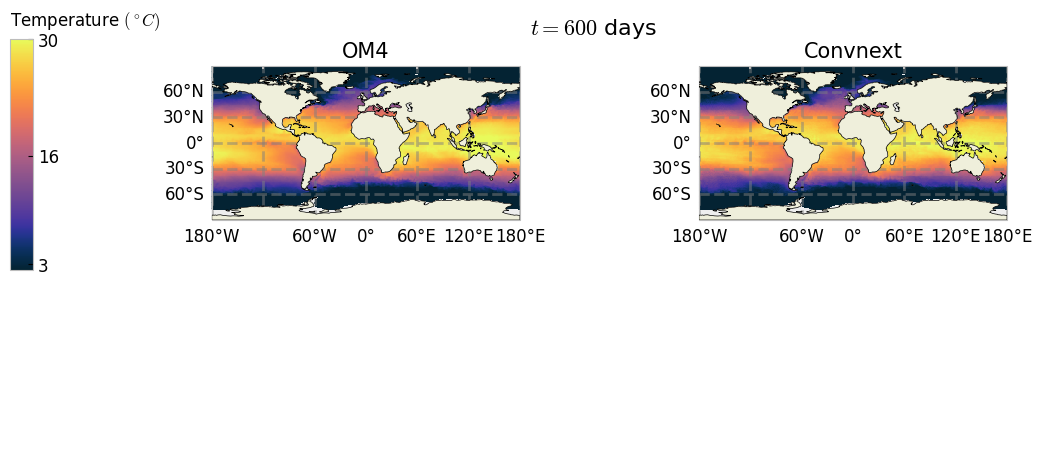

In [42]:
var_list = {"1": r"v", "0": r"u", "2": r"T"}
networks = pred_names + [network]
networks = networks
model_pred_saved_nets_removed = model_pred_saved_nets
fig, plts, a = get_initial_snapshot_fig(
    networks,
    N_plot,
    region,
    grids,
    test_data,
    wet_nan,
    model_pred_saved_nets_removed,
    mean_out,
    std_out,
    ind_plot,
    Nb,
)

In [43]:
def update_snapshot(i):
    print("Frame : ", i)
    plts[0].set_array(
        (
            test_data[i][1][ind_plot].cpu() * wet_nan * std_out[ind_plot]
            + mean_out[ind_plot]
        ).flatten()
    )
    for j, model_pred in enumerate(model_pred_saved_nets_removed):
        plts[j + 1].set_array((model_pred[i, :, :, ind_plot] * wet_nan).flatten())
    a.set_text(r"$t = " + str(i + 1) + "$ days " + timestep_str)

In [44]:
var_list = {"1": r"v", "0": r"u", "2": r"T", "KE": r"KE"}
anim = FuncAnimation(
    fig, update_snapshot, interval=100, frames=range(0, args.N_test, 2)
)
anim.save(
    (
        Path(output_dir)
        / (
            post_model_name
            + "_"
            + str(level)
            + "_"
            + region
            + "_"
            + var_list[str(ind_plot)]
            + ".gif"
        )
    )
)

MovieWriter ffmpeg unavailable; using Pillow instead.


Frame :  0
Frame :  0
Frame :  2
Frame :  4
Frame :  6
Frame :  8
Frame :  10
Frame :  12
Frame :  14
Frame :  16
Frame :  18
Frame :  20
Frame :  22
Frame :  24
Frame :  26
Frame :  28
Frame :  30
Frame :  32
Frame :  34
Frame :  36
Frame :  38
Frame :  40
Frame :  42
Frame :  44
Frame :  46
Frame :  48
Frame :  50
Frame :  52
Frame :  54
Frame :  56
Frame :  58
Frame :  60
Frame :  62
Frame :  64
Frame :  66
Frame :  68
Frame :  70
Frame :  72
Frame :  74
Frame :  76
Frame :  78
Frame :  80
Frame :  82
Frame :  84
Frame :  86
Frame :  88
Frame :  90
Frame :  92
Frame :  94
Frame :  96
Frame :  98
Frame :  100
Frame :  102
Frame :  104
Frame :  106
Frame :  108
Frame :  110
Frame :  112
Frame :  114
Frame :  116
Frame :  118
Frame :  120
Frame :  122
Frame :  124
Frame :  126
Frame :  128
Frame :  130
Frame :  132
Frame :  134
Frame :  136
Frame :  138
Frame :  140
Frame :  142
Frame :  144
Frame :  146
Frame :  148
Frame :  150
Frame :  152
Frame :  154
Frame :  156
Frame :  158
Fram

#### Animation (KE)

In [41]:
def get_stats(
    zarr_path,
    region,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
):
    mean_out = test_data.norm_vals["m_out"]
    std_out = test_data.norm_vals["s_out"]
    rmse = 1e7
    # for rand_int in range(1, 4):
    #     model_pred_temp = (
    #         xr.open_zarr(
    #             zarr_path
    #             / (
    #                 "Pred_lateral_Fast_Data_025_"
    #                 + region
    #                 + "_in_"
    #                 + str_in
    #                 + "ext_"
    #                 + str_ext
    #                 + "N_samples_"
    #                 + str(N_samples)
    #                 + "_rand_seed_"
    #                 + str(rand_int)
    #                 + ".zarr"
    #             )
    #         )
    #         .to_array()
    #         .to_numpy()
    #         .squeeze()
    #     )

    # long_KE_net, long_KE_true = gen_KE_range(0, N_mean, test_data, model_pred_temp)

    # print(long_KE_net.shape)
    # print(long_KE_true.shape)

    # rmse_KE = np.sqrt(((long_KE_net - long_KE_true) ** 2).mean())

    # print("RMSE: ", rmse_KE)
    # if rmse_KE < rmse:
    #     print("Best RMSE...")
    #     rmse = rmse_KE
    #     rand_best = rand_int
    #     long_KE_best = long_KE_net

    model_pred_temp = (
        xr.open_zarr(
            zarr_path
            / (
                "Pred_lateral_Fast_Data_025_"
                + region
                + "_all_"
                + "N_samples_"
                + str(N_samples)
                + "_rand_seed_"
                + str(1)
                + ".zarr"
            )
        )
        .sel(time=slice(0, N_mean))
        .to_array()
        .to_numpy()
        .squeeze()
    )

    long_KE_net, long_KE_true = gen_KE_range(0, N_mean, test_data, model_pred_temp)
    rmse_KE = np.sqrt(((long_KE_net - long_KE_true) ** 2).mean())

    return long_KE_net, long_KE_true, 1

In [42]:
print("Plot animation begin...")

N_plot = args.N_test
ind_plot = "KE"

print("Collecting stats: ", network)
long_KE_best, long_KE_true, rand_best = get_stats(
    pred_model_path,
    region,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_plot,
)

model_pred_saved_nets = []
for i, model_pred_path in enumerate(pred_paths):
    print("Collecting stats: ", pred_names[i])
    long_KE_best_i, _, _ = get_stats(
        Path(model_pred_path),
        pred_region,
        str_in,
        str_ext,
        test_data,
        area,
        wet_bool,
        N_plot,
    )
    model_pred_saved_nets.append(long_KE_best_i)

model_pred_saved_nets.append(long_KE_best)

Plot animation begin...


In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


def get_initial_snapshot_fig(
    network_names,
    N_plot,
    region,
    grids,
    test_data,
    wet_nan,
    model_preds,
    mean_out,
    std_out,
    Nb,
):
    plt.rcParams.update({"font.size": 12})
    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $(m/s)$",
        "2": r"Temperature $( ^\circ C )$",
        "KE": r"Kinetic Energy $( J/m^2 )$",
    }
    if len(model_preds) > 1:
        fig, axs = plt.subplots(
            2,
            3,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    elif len(model_preds) == 1:
        fig, axs = plt.subplots(
            2,
            2,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.1,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    else:
        print("0 entries in model_preds")
        return

    T_plot = N_plot

    vmin = 0
    vmax = 60

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal

    # Ground Truth
    plt0 = axs[0, 0].pcolormesh(
        x_plot,
        y_plot,
        long_KE_true[N_plot - 1],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title("{0}".format(dataset_name), size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    if len(model_preds) > 1:
        new_pos = [
            pos.x0 - 0.42,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed
    else:
        new_pos = [
            pos.x0 - 0.55,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=12)  # Set the font size for tick labels
    cbar.set_ticks([np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)])

    cbar.ax.set_title(var_list[str(ind_plot)], fontsize=12, loc="left", pad=10)

    fig.delaxes(cax)

    plts = [plt0]
    for i, model_pred in enumerate(model_preds):
        if model_pred is not None:
            if i == 0:
                idy, idx = 0, 1
            elif i == 1:
                idy, idx = 0, 2
            elif i == 2:
                idy, idx = 1, 1
            elif i == 3:
                idy, idx = 1, 2

            plt_temp = axs[idy, idx].pcolormesh(
                x_plot,
                y_plot,
                model_pred[T_plot - 1],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                shading="auto",
            )

            axs[idy, idx].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[idy, idx].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[idy, idx].set_title(network_names[i], size=15)
            plts.append(plt_temp)

    axs[1, 0].set_axis_off()
    if len(model_preds) == 1:
        axs[1, 1].set_axis_off()
    if len(model_preds) == 2:
        axs[1, 1].set_axis_off()
        axs[1, 2].set_axis_off()
    if len(model_preds) == 3:
        axs[1, 2].set_axis_off()

    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    a = fig.suptitle(
        r"$t = " + str(N_plot) + "$ days " + timestep_str,
        fontsize=16,
    )
    return fig, plts, a

/state/partition1/job-48305573/ipykernel_2406105/2880938472.py:122: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)


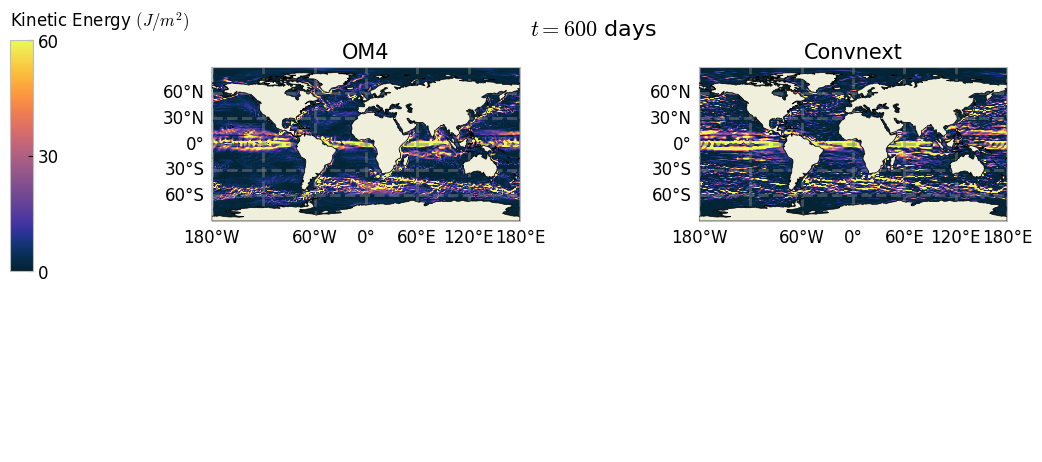

In [53]:
var_list = {"1": r"v", "0": r"u", "2": r"T", "KE": r"KE"}
networks = pred_names + [network]
model_pred_saved_nets_removed = model_pred_saved_nets
fig, plts, a = get_initial_snapshot_fig(
    networks,
    N_plot,
    region,
    grids,
    test_data,
    wet_nan,
    model_pred_saved_nets_removed,
    mean_out,
    std_out,
    Nb,
)

In [54]:
def update_snapshot(i):
    print("Frame : ", i)
    plts[0].set_array((long_KE_true[i]).flatten())
    for j, model_pred in enumerate(model_pred_saved_nets_removed):
        plts[j + 1].set_array((model_pred[i]).flatten())
    a.set_text(r"$t = " + str(i + 1) + "$ days " + timestep_str)

In [59]:
var_list = {"1": r"v", "0": r"u", "2": r"T", "KE": r"KE"}
anim = FuncAnimation(
    fig, update_snapshot, interval=100, frames=range(0, args.N_test, 2)
)
anim.save(
    (
        Path(output_dir)
        / (post_model_name + "_" + region + "_" + var_list[str(ind_plot)] + ".gif")
    )
)

MovieWriter ffmpeg unavailable; using Pillow instead.


Frame :  0
Frame :  0
Frame :  2


/home/sd5313/.local/lib/python3.10/site-packages/matplotlib/animation.py:887: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you have outputted the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


Frame :  4
Frame :  6
Frame :  8
Frame :  10
Frame :  12
Frame :  14
Frame :  16
Frame :  18
Frame :  20
Frame :  22
Frame :  24
Frame :  26
Frame :  28
Frame :  30
Frame :  32
Frame :  34
Frame :  36
Frame :  38
Frame :  40
Frame :  42
Frame :  44
Frame :  46
Frame :  48
Frame :  50
Frame :  52
Frame :  54
Frame :  56
Frame :  58
Frame :  60
Frame :  62
Frame :  64
Frame :  66
Frame :  68
Frame :  70
Frame :  72
Frame :  74
Frame :  76
Frame :  78
Frame :  80
Frame :  82
Frame :  84
Frame :  86
Frame :  88
Frame :  90
Frame :  92
Frame :  94
Frame :  96
Frame :  98
Frame :  100
Frame :  102
Frame :  104
Frame :  106
Frame :  108
Frame :  110
Frame :  112
Frame :  114
Frame :  116
Frame :  118
Frame :  120
Frame :  122
Frame :  124
Frame :  126
Frame :  128
Frame :  130
Frame :  132
Frame :  134
Frame :  136
Frame :  138
Frame :  140
Frame :  142
Frame :  144
Frame :  146
Frame :  148
Frame :  150
Frame :  152
Frame :  154
Frame :  156
Frame :  158
Frame :  160
Frame :  162
Frame :  16

#### sensitivity

In [8]:
pred_names

[]

In [33]:
def plot_metrics_KE_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    KE_true,
    KEs,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(KE_true)

    # KE
    rho = 1020
    for i, KE_i in enumerate(KEs):
        # if i == 0 or i == 1:
        #     continue
        if KE_i is not None:
            plt.plot(
                np.arange(start, end),
                KE_i[0][start:end] * rho,
                c=clist[0],
                label=f"{network_names[i]+ '_0'}",
            )
            plt.plot(
                np.arange(start, end),
                KE_i[1][start:end] * rho,
                c=clist[1],
                label=f"{network_names[i]+ '_1'}",
            )
            plt.plot(
                np.arange(start, end),
                KE_i[2][start:end] * rho,
                c=clist[2],
                label=f"{network_names[i]+ '_2'}",
            )

    plt.plot(
        np.arange(start, end),
        KE_true.mean(axis=0)[start:end] * rho,
        "--k",
        label="{0}".format(dataset_name),
    )
    plt.xlabel(r"time $( days" + timestep_str + ")$")
    plt.ylabel(r"KE $( J/m^2 )$")
    plt.xlim([start, end])
    plt.legend(
        bbox_to_anchor=(0, 1.02, 1, 0.2),
        loc="lower left",
        fancybox=True,
        ncol=len(KEs) + 1,
    )
    plt.show()

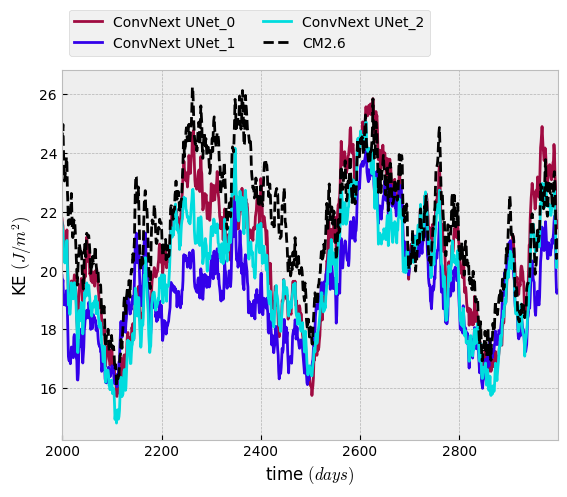

In [34]:
plot_metrics_KE_seeds(
    pred_names + [network],
    region + "_Long_",
    str_save,
    output_dir,
    KE_true,
    KE_saved,
)

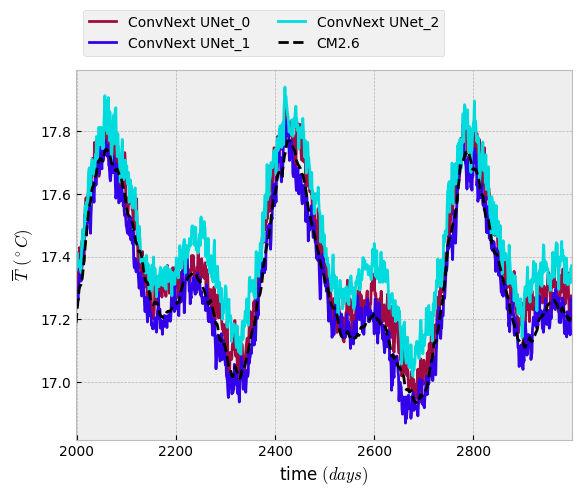

In [32]:
def plot_metrics_T_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    T_true,
    Ts,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(T_true)

    rho = 1020
    for i, T_i in enumerate(Ts):
        # if i == 0 or i == 1:
        #     continue
        if T_i is not None:
            plt.plot(
                np.arange(start, end),
                T_i[0][start:end],
                c=clist[0],
                label=f"{network_names[i] + '_0'}",
            )
            plt.plot(
                np.arange(start, end),
                T_i[1][start:end],
                c=clist[1],
                label=f"{network_names[i] + '_1'}",
            )
            plt.plot(
                np.arange(start, end),
                T_i[2][start:end],
                c=clist[2],
                label=f"{network_names[i] + '_2'}",
            )

    plt.plot(
        np.arange(start, end),
        T_true.mean(axis=0)[start:end],
        "--k",
        label="{0}".format(dataset_name),
    )
    plt.xlabel(r"time $( days" + timestep_str + ")$")
    plt.ylabel(r"$\overline{T}$ $( ^\circ C )$")
    plt.xlim([start, end])
    plt.legend(
        bbox_to_anchor=(0, 1.02, 1, 0.2),
        loc="lower left",
        fancybox=True,
        ncol=len(Ts) + 1,
    )

    plt.show()


plot_metrics_T_seeds(
    pred_names + [network],
    region + "_Long_",
    str_save,
    output_dir,
    T_true,
    T_saved,
)